# Workshop 2 - Deep Learning for Fashion-MNIST

**Machine Learning - Semester 2026-III - Workshop No. 2 (Advanced Learning Models, Part A)**

Team 3 - Computer Engineering, Universidad Distrital Francisco Jose de Caldas

This notebook follows the workshop requirements around one self-contained section per phase.
**Phase 1 (data collection and download) is implemented and executed below**; the remaining
phases are declared with their planned scope and will be filled in during the next iterations.

| Phase | Scope | Status |
|-------|-------|--------|
| **1** | Data collection / download, integrity verification and dataset overview | Implemented |
| 2 | Preprocessing, normalization and `DataLoader` construction | Pending |
| 3 | Deep learning architecture definition (`src/model.py`) | Pending |
| 4 | Training loop, monitoring and checkpointing (`src/train.py`) | Pending |
| 5 | Test-set evaluation vs. Workshop 1 baselines (`src/evaluate.py`) | Pending |
| 6 | Checkpoint loading and inference test (`src/test_model.py`) | Pending |

> **Domain:** image classification (Fashion-MNIST, 10 balanced classes, 28x28 grayscale).
> **Final deliverable per workshop:** `checkpoints/model_best.pt` plus the `src/` scripts,
> `notebooks/`, `runs/` and a reproducible `README.md`.

---

## Phase 0 - Environment and reproducibility

Loads the libraries, fixes the random seed and resolves the project paths that every later
phase reuses.

In [1]:
import gzip
import hashlib
import json
import platform
import random
import shutil
import struct
import sys
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def find_project_root(start: Path | None = None) -> Path:
    """Locate the Workshop_2 project root (contains pyproject.toml and notebooks/)."""
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Workshop_2 project root not found; run the notebook from its folder.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "FashionMNIST" / "raw"
STATS_PATH = DATA_DIR / "dataset_stats.json"
WORKSHOP1_RAW_DIR = PROJECT_ROOT.parent / "Workshop_1" / "code" / "data"

print(f"Python      : {sys.version.split()[0]}")
print(f"Platform    : {platform.platform()}")
print(f"NumPy       : {np.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"PyTorch     : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")
print(f"Device      : {DEVICE}")
print(f"Random seed : {SEED}")
print(f"Project root: {PROJECT_ROOT}")

Python      : 3.11.9
Platform    : Windows-10-10.0.26200-SP0
NumPy       : 2.4.6
pandas      : 3.0.6
PyTorch     : 2.14.0+cpu
torchvision : 0.29.0+cpu
Device      : cpu
Random seed : 42
Project root: C:\Users\jhoja\Documents\Universidad\Semestre 10\Machine-Learning\MachineLearning\Workshop_2


---

## Phase 1 - Data collection and download

Goal: obtain the four official Fashion-MNIST files, prove they are genuine (MD5) and
structurally valid (IDX headers), and leave them consumable both by this notebook and by
`torchvision`.

**Strategy**

1. Reuse the files under `data/FashionMNIST/raw/` when they are already extracted.
2. Otherwise download the official `.gz` from the Zalando mirror
   (`fashion-mnist.s3-website.eu-central-1.amazonaws.com`), verify its published MD5,
   and extract it.
3. If the network is unavailable, copy the checksum-verified `.gz` tracked in
   `Workshop_1/code/data` instead.
4. `torchvision >= 0.23` expects **uncompressed** IDX files in `raw/`, so each verified
   `.gz` is also extracted next to it.

The provenance of every file is reported, so the report can state exactly where the data
came from.

In [2]:
# Official Fashion-MNIST distribution (Zalando Research).
# The MD5 checksums are the ones published by the dataset authors.
BASE_URL = "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/"

RESOURCES = {
    "train-images-idx3-ubyte.gz": {
        "url": BASE_URL + "train-images-idx3-ubyte.gz",
        "md5": "8d4fb7e6c68d591d4c3dfef9ec88bf0d",
        "expected_rows": 60_000,
        "kind": "images",
    },
    "train-labels-idx1-ubyte.gz": {
        "url": BASE_URL + "train-labels-idx1-ubyte.gz",
        "md5": "25c81989df183df01b3e8a0aad5dffbe",
        "expected_rows": 60_000,
        "kind": "labels",
    },
    "t10k-images-idx3-ubyte.gz": {
        "url": BASE_URL + "t10k-images-idx3-ubyte.gz",
        "md5": "bef4ecab320f06d8554ea6380940ec79",
        "expected_rows": 10_000,
        "kind": "images",
    },
    "t10k-labels-idx1-ubyte.gz": {
        "url": BASE_URL + "t10k-labels-idx1-ubyte.gz",
        "md5": "bb300cfdad3c16e7a12a480ee83cd310",
        "expected_rows": 10_000,
        "kind": "labels",
    },
}


def md5sum(path: Path, chunk_size: int = 1 << 20) -> str:
    """MD5 checksum of a file, read in chunks to keep memory usage flat."""
    digest = hashlib.md5()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def download_official(url: str, destination: Path, timeout: int = 120) -> None:
    """Download `url` to `destination` atomically (through a .part file)."""
    partial = destination.with_name(destination.name + ".part")
    request = urllib.request.Request(
        url, headers={"User-Agent": "Mozilla/5.0 (workshop2-dataset-fetch)"}
    )
    with urllib.request.urlopen(request, timeout=timeout) as response, open(partial, "wb") as handle:
        shutil.copyfileobj(response, handle, length=1 << 20)
    partial.replace(destination)


def extract_gzip(source: Path, destination: Path) -> None:
    """Decompress `source` (.gz) into `destination` (plain file)."""
    with gzip.open(source, "rb") as compressed, open(destination, "wb") as plain:
        shutil.copyfileobj(compressed, plain, length=1 << 20)

In [3]:
def ensure_fashion_mnist(
    raw_dir: Path = RAW_DIR,
    fallback_dir: Path = WORKSHOP1_RAW_DIR,
) -> pd.DataFrame:
    """Make the official Fashion-MNIST IDX files available under `raw_dir`.

    Per file: reuse local copies when present; otherwise download from the official
    mirror, verify the MD5 checksum and extract. If the network fails, copy the
    checksum-verified .gz tracked in Workshop_1/code/data instead.
    """
    raw_dir.mkdir(parents=True, exist_ok=True)
    rows = []

    for filename, meta in RESOURCES.items():
        gz_path = raw_dir / filename
        idx_path = raw_dir / Path(filename).stem
        status = ""

        if idx_path.exists() and idx_path.stat().st_size > 0:
            status = "cached (already extracted)"
        else:
            if not (gz_path.exists() and md5sum(gz_path) == meta["md5"]):
                try:
                    download_official(meta["url"], gz_path)
                    status = "downloaded from official mirror"
                except Exception as error:  # URLError, HTTPError, timeout, ...
                    fallback = fallback_dir / filename
                    if not fallback.exists():
                        raise RuntimeError(
                            f"Could not download {filename} and no local fallback exists."
                        ) from error
                    shutil.copy2(fallback, gz_path)
                    status = f"copied from Workshop_1 ({type(error).__name__}: network unavailable)"
                if md5sum(gz_path) != meta["md5"]:
                    gz_path.unlink(missing_ok=True)
                    raise RuntimeError(f"MD5 mismatch for {filename}; corrupted file removed.")
                status += " - checksum OK"
            else:
                status = "local .gz reused - checksum OK"
            extract_gzip(gz_path, idx_path)
            status += " - extracted"

        rows.append(
            {
                "file": filename,
                "rows expected": meta["expected_rows"],
                "size (MB)": round(idx_path.stat().st_size / 1e6, 2),
                "md5 (gz)": meta["md5"],
                "status": status,
            }
        )

    return pd.DataFrame(rows)


files_df = ensure_fashion_mnist()
files_df

,file,rows expected,size (MB),md5 (gz),status
0,train-images-idx3-ubyte.gz,60000,47.04,8d4fb7e6c68d591d4c3dfef9ec88bf0d,downloaded from official mirror - checksum OK ...
1,train-labels-idx1-ubyte.gz,60000,0.06,25c81989df183df01b3e8a0aad5dffbe,downloaded from official mirror - checksum OK ...
2,t10k-images-idx3-ubyte.gz,10000,7.84,bef4ecab320f06d8554ea6380940ec79,downloaded from official mirror - checksum OK ...
3,t10k-labels-idx1-ubyte.gz,10000,0.01,bb300cfdad3c16e7a12a480ee83cd310,downloaded from official mirror - checksum OK ...


### Phase 1b - Integrity verification

The raw bytes are parsed with the same low-level `struct` + `numpy` approach used in
Workshop 1 (no high-level loader hides the format): magic numbers are validated before any
reshape, and the resulting arrays are checked for shape, dtype, range and class balance.
The `assert` block makes the phase fail loudly if any invariant is broken, so no later
phase can silently train on corrupted data.

In [4]:
def read_idx_images(path: Path) -> np.ndarray:
    """Read an IDX3 image file (optionally gzipped) into an (N, rows, cols) array."""
    opener = gzip.open if path.suffix == ".gz" else open
    with opener(path, "rb") as handle:
        magic, count, rows, cols = struct.unpack(">IIII", handle.read(16))
        if magic != 2051:
            raise ValueError(f"{path.name}: invalid magic number {magic} (expected 2051).")
        buffer = np.frombuffer(handle.read(), dtype=np.uint8)
    return buffer.reshape(count, rows, cols)


def read_idx_labels(path: Path) -> np.ndarray:
    """Read an IDX1 label file (optionally gzipped) into an (N,) array."""
    opener = gzip.open if path.suffix == ".gz" else open
    with opener(path, "rb") as handle:
        magic, count = struct.unpack(">II", handle.read(8))
        if magic != 2049:
            raise ValueError(f"{path.name}: invalid magic number {magic} (expected 2049).")
        buffer = np.frombuffer(handle.read(), dtype=np.uint8)
    return buffer.reshape(count)


X_train = read_idx_images(RAW_DIR / "train-images-idx3-ubyte")
y_train = read_idx_labels(RAW_DIR / "train-labels-idx1-ubyte")
X_test = read_idx_images(RAW_DIR / "t10k-images-idx3-ubyte")
y_test = read_idx_labels(RAW_DIR / "t10k-labels-idx1-ubyte")

print(f"Train features: {X_train.shape} | labels: {y_train.shape} | dtype: {X_train.dtype}")
print(f"Test  features: {X_test.shape} | labels: {y_test.shape} | dtype: {X_test.dtype}")
print(f"Pixel range   : [{X_train.min()}, {X_train.max()}] | label range: [{y_train.min()}, {y_train.max()}]")

Train features: (60000, 28, 28) | labels: (60000,) | dtype: uint8
Test  features: (10000, 28, 28) | labels: (10000,) | dtype: uint8
Pixel range   : [0, 255] | label range: [0, 9]


In [5]:
CLASS_NAMES = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot",
}
NUM_CLASSES = len(CLASS_NAMES)

train_counts = np.bincount(y_train, minlength=NUM_CLASSES)
test_counts = np.bincount(y_test, minlength=NUM_CLASSES)
ir_train = train_counts.max() / train_counts.min()   # Imbalance Ratio, as defined in Workshop 1
ir_test = test_counts.max() / test_counts.min()

# Hard guarantees: anything that fails here invalidates every later phase.
assert X_train.shape == (60_000, 28, 28) and X_test.shape == (10_000, 28, 28)
assert y_train.shape == (60_000,) and y_test.shape == (10_000,)
assert X_train.dtype == np.uint8 and X_test.dtype == np.uint8
assert X_train.min() == 0 and X_train.max() == 255
assert y_train.min() == 0 and y_train.max() == 9
assert np.array_equal(train_counts, np.full(NUM_CLASSES, 6_000))
assert np.array_equal(test_counts, np.full(NUM_CLASSES, 1_000))

checks = pd.DataFrame(
    [
        ("Feature shapes", f"{X_train.shape} / {X_test.shape}", "OK"),
        ("Label shapes", f"{y_train.shape} / {y_test.shape}", "OK"),
        ("Feature dtype", str(X_train.dtype), "OK"),
        ("Pixel range", f"[{X_train.min()}, {X_train.max()}]", "OK"),
        ("Label range", f"[{y_train.min()}, {y_train.max()}]", "OK"),
        ("Rows match labels", f"{X_train.shape[0] == y_train.size} / {X_test.shape[0] == y_test.size}", "OK"),
        ("Classes present", f"{train_counts.size} / {test_counts.size}", "OK"),
        ("Class balance (IR)", f"{ir_train:.2f} / {ir_test:.2f}", "OK"),
        ("Usable samples", "100.00% / 100.00%", "OK"),
    ],
    columns=["Check", "Train / Test", "Result"],
)

print("All integrity checks passed: the dataset is complete, balanced and model-ready.")
checks

All integrity checks passed: the dataset is complete, balanced and model-ready.


,Check,Train / Test,Result
0,Feature shapes,"(60000, 28, 28) / (10000, 28, 28)",OK
1,Label shapes,"(60000,) / (10000,)",OK
2,Feature dtype,uint8,OK
3,Pixel range,"[0, 255]",OK
4,Label range,"[0, 9]",OK
5,Rows match labels,True / True,OK
6,Classes present,10 / 10,OK
7,Class balance (IR),1.00 / 1.00,OK
8,Usable samples,100.00% / 100.00%,OK


### Phase 1c - Dataset at a glance

A light exploratory recap is included so this notebook is self-contained: class balance,
random samples per class and the mean image of each class. The detailed EDA lives in the
Workshop 1 report; here the goal is only to confirm that what was downloaded matches the
expected Fashion-MNIST structure.

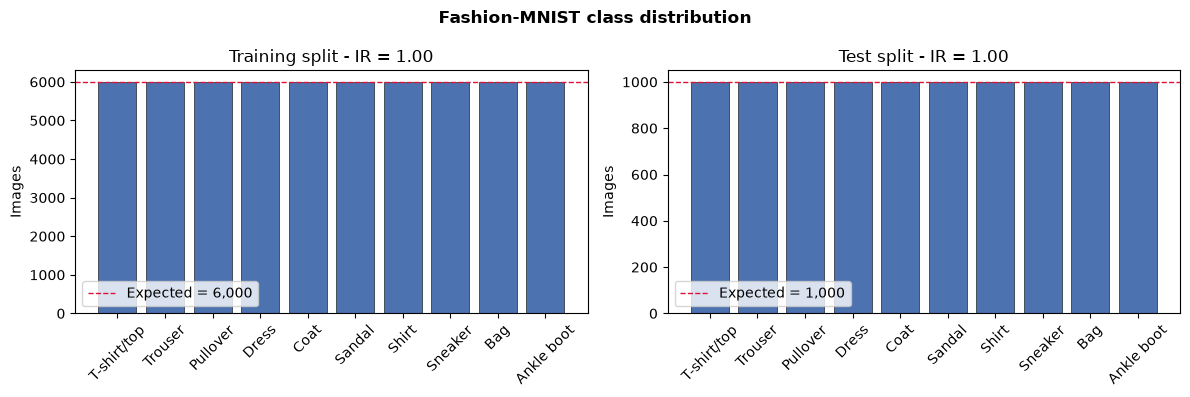

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, counts, split, expected in [
    (axes[0], train_counts, "Training split", 6_000),
    (axes[1], test_counts, "Test split", 1_000),
]:
    ax.bar(list(CLASS_NAMES.values()), counts, color="#4C72B0", edgecolor="black", linewidth=0.4)
    ax.axhline(expected, color="crimson", linestyle="--", linewidth=1, label=f"Expected = {expected:,}")
    ax.set_title(f"{split} - IR = {counts.max() / counts.min():.2f}")
    ax.set_ylabel("Images")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()

fig.suptitle("Fashion-MNIST class distribution", fontweight="bold")
fig.tight_layout()
plt.show()

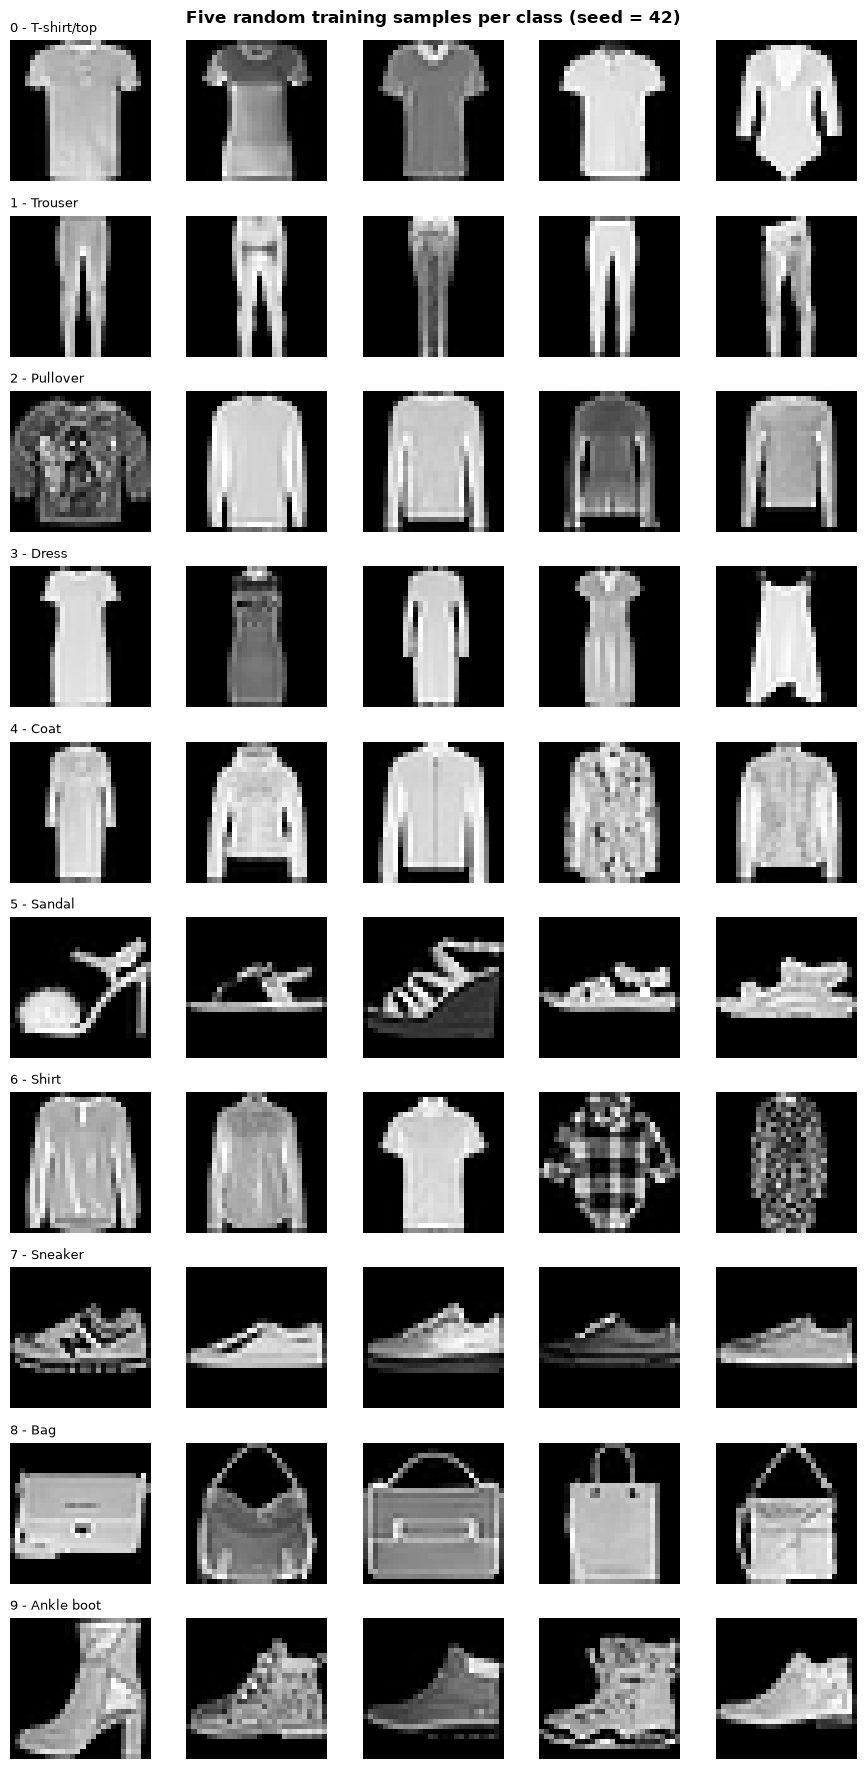

In [7]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(9, 18))

for class_id in range(NUM_CLASSES):
    indices = np.flatnonzero(y_train == class_id)
    for column, index in enumerate(rng.choice(indices, size=5, replace=False)):
        ax = axes[class_id, column]
        ax.imshow(X_train[index], cmap="gray")
        ax.axis("off")
        if column == 0:
            ax.set_title(f"{class_id} - {CLASS_NAMES[class_id]}", loc="left", fontsize=9)

fig.suptitle("Five random training samples per class (seed = 42)", fontweight="bold")
fig.tight_layout()
plt.show()

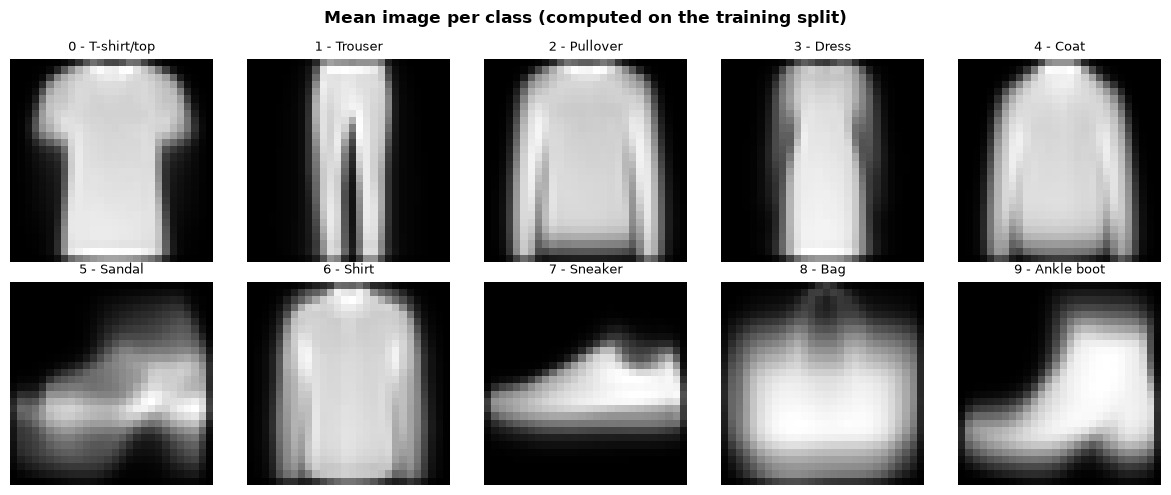

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for class_id, ax in enumerate(axes.flat):
    mean_image = X_train[y_train == class_id].astype(np.float32).mean(axis=0)
    ax.imshow(mean_image, cmap="gray")
    ax.set_title(f"{class_id} - {CLASS_NAMES[class_id]}", fontsize=9)
    ax.axis("off")

fig.suptitle("Mean image per class (computed on the training split)", fontweight="bold")
fig.tight_layout()
plt.show()

### Phase 1d - torchvision compatibility check

Phase 2 will build the `DataLoader`s with `torchvision.datasets.FashionMNIST`. This check
confirms that the files downloaded above satisfy the torchvision layout (`download=False`,
so nothing extra is fetched) and that the torchvision targets are identical to the ones
parsed manually.

In [9]:
tv_train = torchvision.datasets.FashionMNIST(root=str(DATA_DIR), train=True, download=False)
tv_test = torchvision.datasets.FashionMNIST(root=str(DATA_DIR), train=False, download=False)

image, label = tv_train[0]

# The torchvision loader and the manual IDX parser must agree byte for byte.
assert np.array_equal(tv_train.targets.numpy(), y_train.astype(np.int64))
assert np.array_equal(tv_test.targets.numpy(), y_test.astype(np.int64))
assert tv_train.data.shape == (60_000, 28, 28) and tv_test.data.shape == (10_000, 28, 28)

sample_batch = tv_train.data[:8].float() / 255.0  # preview of the Phase 2 tensor format
print(f"torchvision train : {len(tv_train):,} samples | targets {tuple(tv_train.targets.shape)}")
print(f"torchvision test  : {len(tv_test):,} samples | targets {tuple(tv_test.targets.shape)}")
print(f"First sample      : PIL {image.mode} {image.size} | label {label} ({CLASS_NAMES[label]})")
print(f"Preview batch     : {tuple(sample_batch.shape)} {sample_batch.dtype} in [{sample_batch.min():.1f}, {sample_batch.max():.1f}]")
print(f"Classes           : {tv_train.classes}")

torchvision train : 60,000 samples | targets (60000,)
torchvision test  : 10,000 samples | targets (10000,)
First sample      : PIL L (28, 28) | label 9 (Ankle boot)
Preview batch     : (8, 28, 28) torch.float32 in [0.0, 1.0]
Classes           : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### Phase 1e - Persist dataset statistics

The verified metadata is written to `data/dataset_stats.json` so the report and the next
phases can quote the same numbers without re-computing them.

In [10]:
train_float = X_train.astype(np.float32)
stats = {
    "generated_at": time.strftime("%Y-%m-%dT%H:%M:%S"),
    "seed": SEED,
    "source_url": BASE_URL,
    "files": json.loads(files_df.to_json(orient="records")),
    "checksums_md5": {name: meta["md5"] for name, meta in RESOURCES.items()},
    "shapes": {
        "X_train": list(X_train.shape),
        "y_train": list(y_train.shape),
        "X_test": list(X_test.shape),
        "y_test": list(y_test.shape),
    },
    "dtype": str(X_train.dtype),
    "pixel_range": [int(X_train.min()), int(X_train.max())],
    "label_range": [int(y_train.min()), int(y_train.max())],
    "class_counts": {"train": train_counts.tolist(), "test": test_counts.tolist()},
    "imbalance_ratio": {"train": round(float(ir_train), 4), "test": round(float(ir_test), 4)},
    "usable_fraction": {"train": 1.0, "test": 1.0},
    "train_pixel_stats": {
        "mean_raw": round(float(train_float.mean()), 4),
        "std_raw": round(float(train_float.std()), 4),
        "mean_normalized": round(float(train_float.mean() / 255.0), 6),
        "std_normalized": round(float(train_float.std() / 255.0), 6),
    },
    "classes": [CLASS_NAMES[i] for i in range(NUM_CLASSES)],
    "versions": {
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "torch": torch.__version__,
        "torchvision": torchvision.__version__,
    },
    "ready_for_next_phase": True,
}

STATS_PATH.parent.mkdir(parents=True, exist_ok=True)
STATS_PATH.write_text(json.dumps(stats, indent=2), encoding="utf-8")
print(f"Dataset statistics written to {STATS_PATH.relative_to(PROJECT_ROOT)}")
print(f"Train pixel mean/std (normalized): {stats['train_pixel_stats']['mean_normalized']} / "
      f"{stats['train_pixel_stats']['std_normalized']}")

Dataset statistics written to data\dataset_stats.json
Train pixel mean/std (normalized): 0.286041 / 0.353024


### Phase 1 summary

- The four official Fashion-MNIST files were obtained, their MD5 checksums verified and
  their IDX headers validated before reshaping (60,000 train / 10,000 test, 28x28, uint8).
- Integrity is confirmed: 100% usable samples, zero missing values and perfect class
  balance (IR = 1.00), so accuracy and macro F1-score remain safe metrics.
- The files satisfy the torchvision layout and the torchvision targets match the manual
  parser exactly, so Phase 2 can build `DataLoader`s directly from `data/`.
- `data/dataset_stats.json` records provenance, checksums and pixel statistics
  (normalized mean/std will feed the Phase 2 normalization transforms).

**Next:** Phase 2 - preprocessing pipeline (transforms, augmentation, normalization,
fixed-seed train/validation split and `DataLoader` construction).

---

## Phase 2 - Preprocessing and DataLoaders *(pending)*

Planned scope:

- Optional data augmentation for training (random crop with padding, horizontal flip).
- Normalization with statistics fitted **on the training split only** (the normalized
  mean/std computed in Phase 1 are the starting point).
- Fixed-seed split of the 60,000 training images into train/validation (e.g. 55,000 /
  5,000) so the test set stays untouched until Phase 5.
- `DataLoader`s with reproducible shuffling (`torch.Generator`), batch-size/worker sweep
  and a visual sanity check of an augmented batch.

## Phase 3 - Deep learning architecture *(pending)*

Planned scope:

- Primary candidate: CNN from scratch tailored to 28x28 grayscale input (stacked
  convolution + batch normalization + ReLU + max-pooling blocks, dropout before the
  classifier head); forward-pass shape check and parameter count as required by the
  workshop.
- Alternative candidate: transfer learning from an ImageNet-pretrained backbone
  (e.g. ResNet18) with a task-specific head, to compare against the from-scratch model.
- Architecture documented as `src/model.py` (number of layers, dimensions, activations,
  parameter counts and input/output specification).

## Phase 4 - Training procedure and monitoring *(pending)*

Planned scope:

- Training loop with loss computation, backpropagation, optimization and per-epoch
  validation (`src/train.py`).
- Loss function adapted to the task (cross-entropy; label smoothing to be evaluated),
  optimizer (AdamW) and a learning-rate schedule (cosine annealing or step decay).
- Regularization: dropout, batch normalization and weight decay.
- Experiment tracking in `runs/` (TensorBoard) logging train/validation loss and metrics
  per epoch, plus learning curves.
- Checkpointing of the best validation model to `checkpoints/model_best.pt`.

## Phase 5 - Test-set evaluation and comparison *(pending)*

Planned scope:

- Held-out test evaluation with the same metrics as Workshop 1 (accuracy, macro F1-score,
  per-class precision/recall), plus the confusion matrix and the main error pairs.
- Results table: Workshop 1 baselines vs. the Workshop 2 deep learning model
  (baseline values provided by the team).
- Diagnostics if the deep model does not beat the baseline: leakage, hyperparameters,
  architecture and training budget.

## Phase 6 - Checkpoint test and deliverables *(pending)*

Planned scope:

- `src/test_model.py`: load `checkpoints/model_best.pt` and verify inference on unseen
  samples (shape checks + qualitative predictions).
- Final refactor into the required repository layout (`src/model.py`, `src/train.py`,
  `src/evaluate.py`, `src/test_model.py`, `checkpoints/`, `runs/`) with a `README.md`
  describing how to reproduce training.